In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:

!kaggle datasets download -d kausthubkannan/5-flower-types-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset
License(s): other
 58% 140M/242M [00:00<00:00, 1.46GB/s]
100% 242M/242M [00:00<00:00, 923MB/s] 


In [4]:
from zipfile import ZipFile
dataset = '/content/5-flower-types-classification-dataset.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [6]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.preprocessing.image import load_img,ImageDataGenerator

In [7]:
dirs=os.listdir('/content/flower_images')
print(dirs)

['Orchid', 'Lotus', 'Tulip', 'Sunflower', 'Lilly']


In [10]:
print("Number of lily images :",len('/content/flower_images/Lilly'))
print("Number of lotus images :",len('/content/flower_images/Lotus'))
print("Number of rose images :",len('/content/flower_images/Rose'))
print("Number of sunflower images :",len('/content/flower_images/Sunflower'))
print("Number of tulip images :",len('/content/flower_images/Tulip'))

Number of lily images : 28
Number of lotus images : 28
Number of rose images : 27
Number of sunflower images : 32
Number of tulip images : 28


In [11]:
base_dir='/content/flower_images'
img_size=100
batch_size=32

In [12]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size
)
val_ds=tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size
)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.


In [14]:
flower_names=train_ds.class_names
print(flower_names)

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


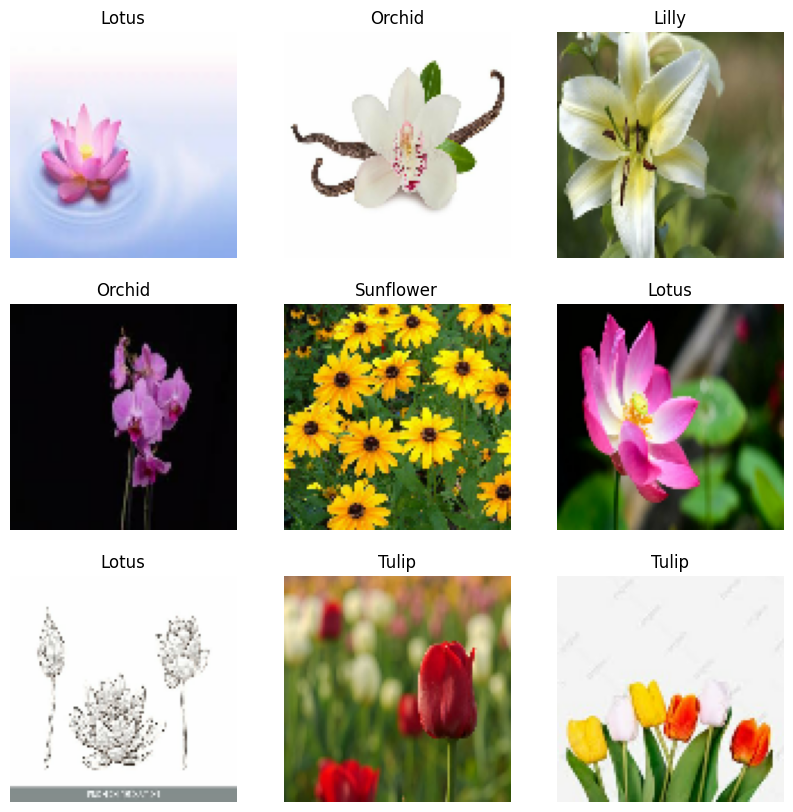

In [17]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(flower_names[labels[i]])
    plt.axis('off')

In [18]:
AUTOTUNE=tf.data.AUTOTUNE

In [19]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [20]:
#Data Agumentation to avoid overfitting
data_augumentation=Sequential([
    layers.RandomFlip('horizontal',input_shape=(img_size,img_size,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


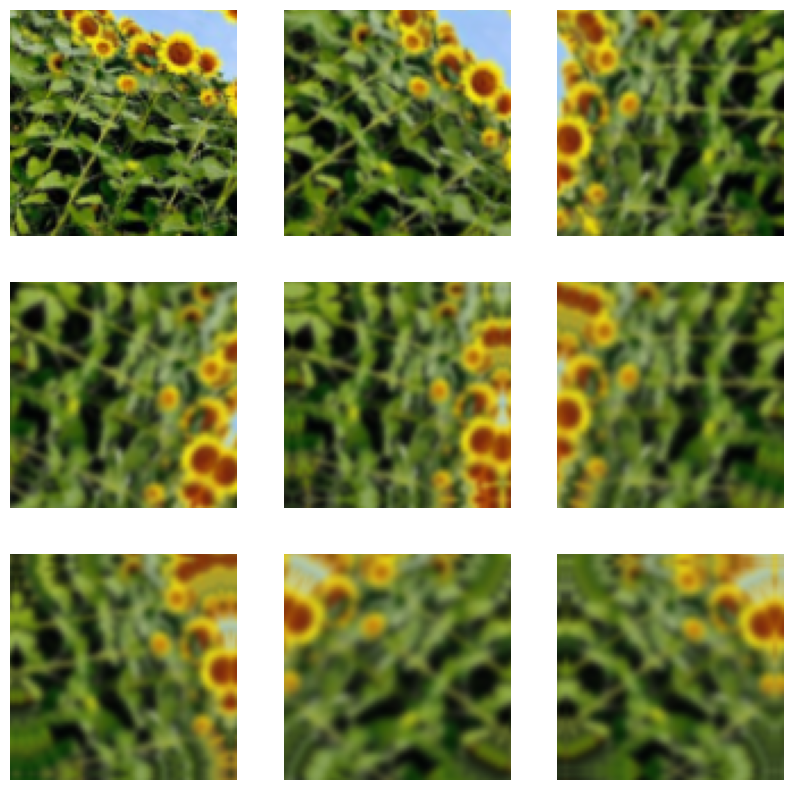

In [22]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

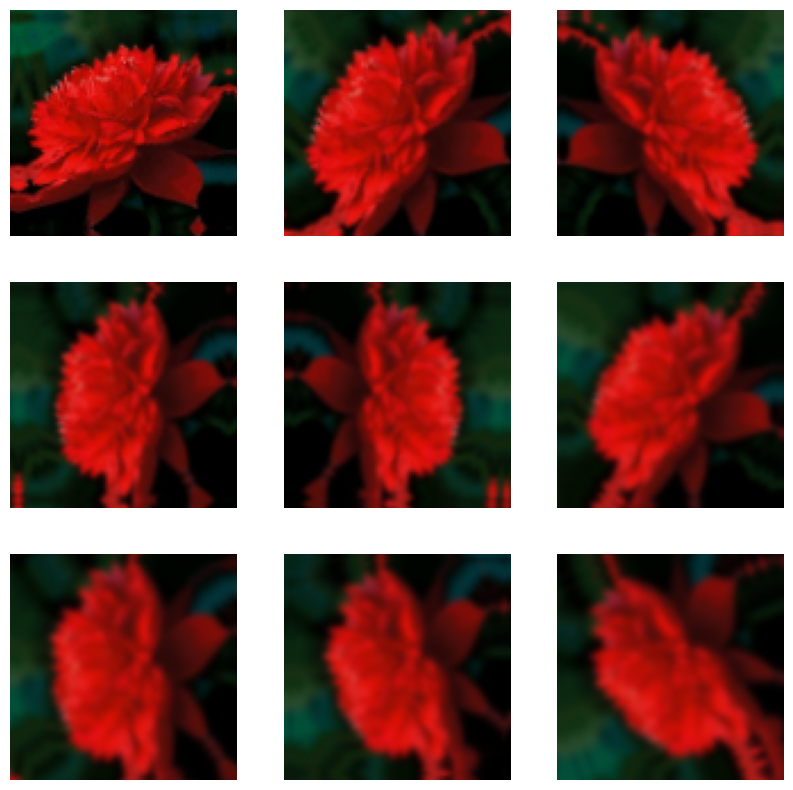

In [23]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

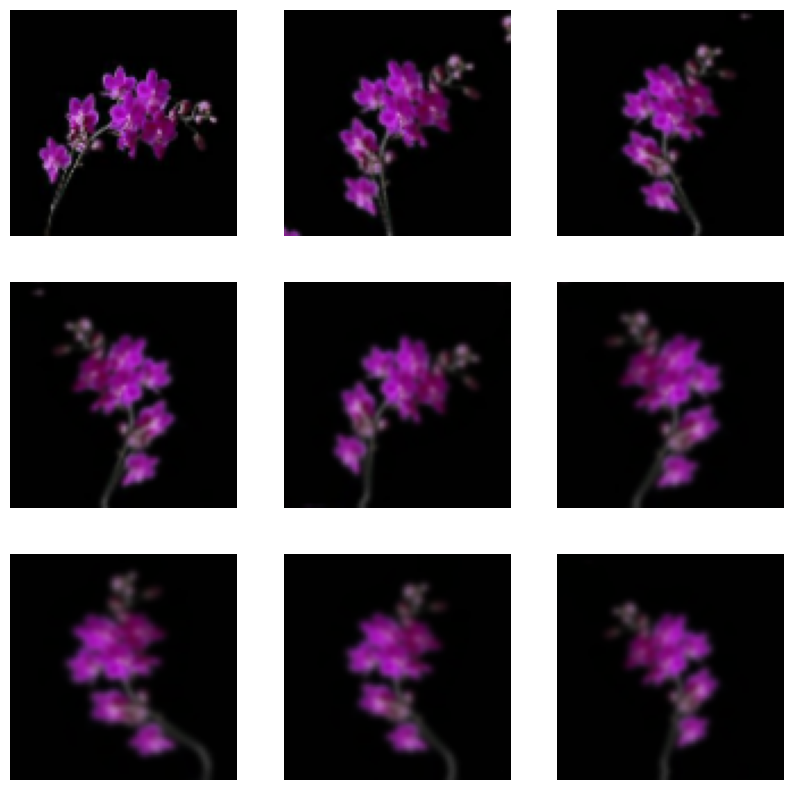

In [24]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

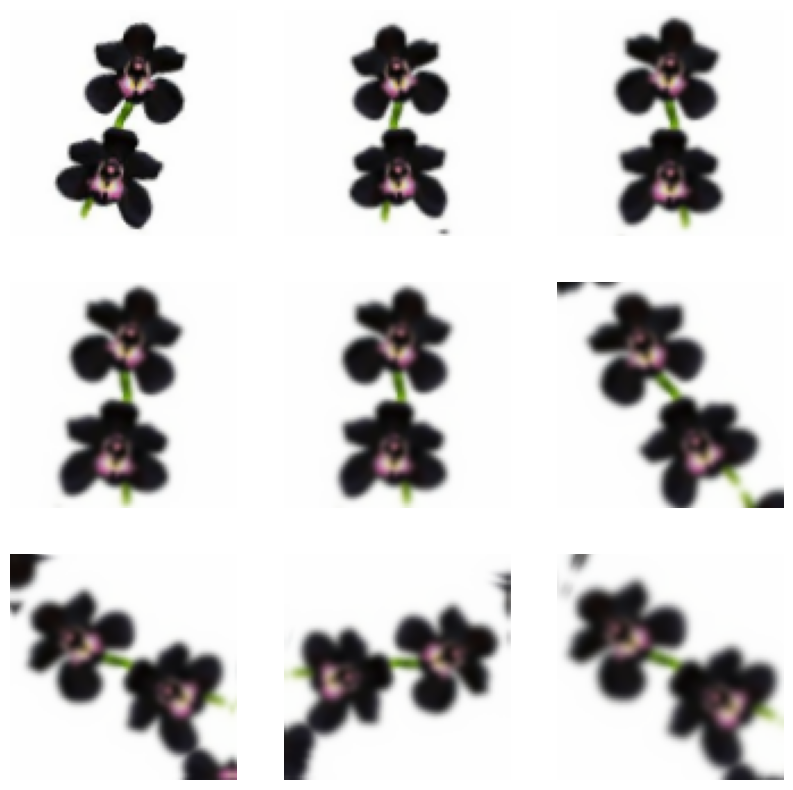

In [25]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

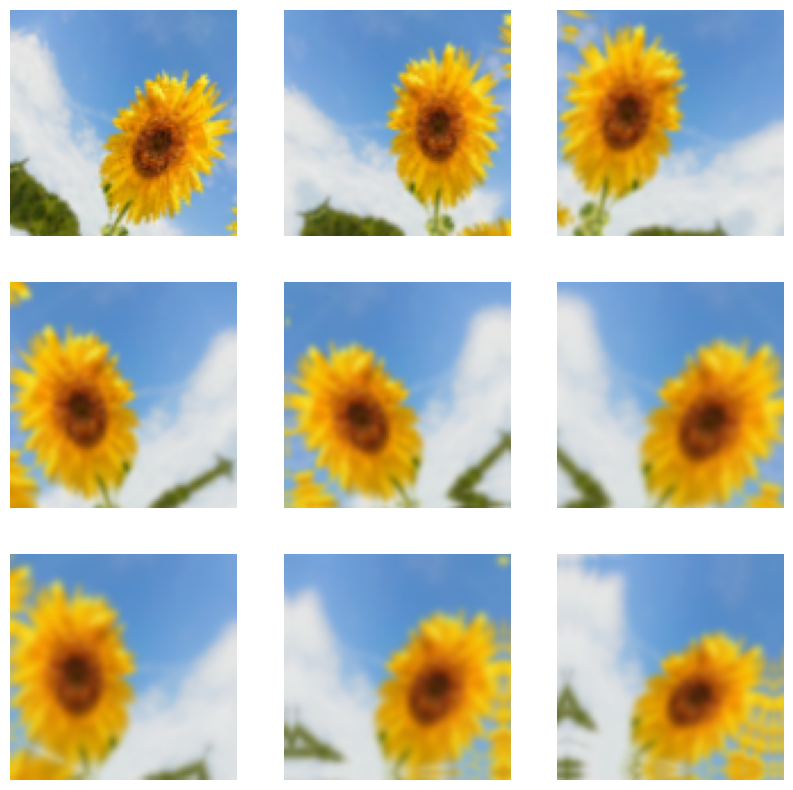

In [26]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

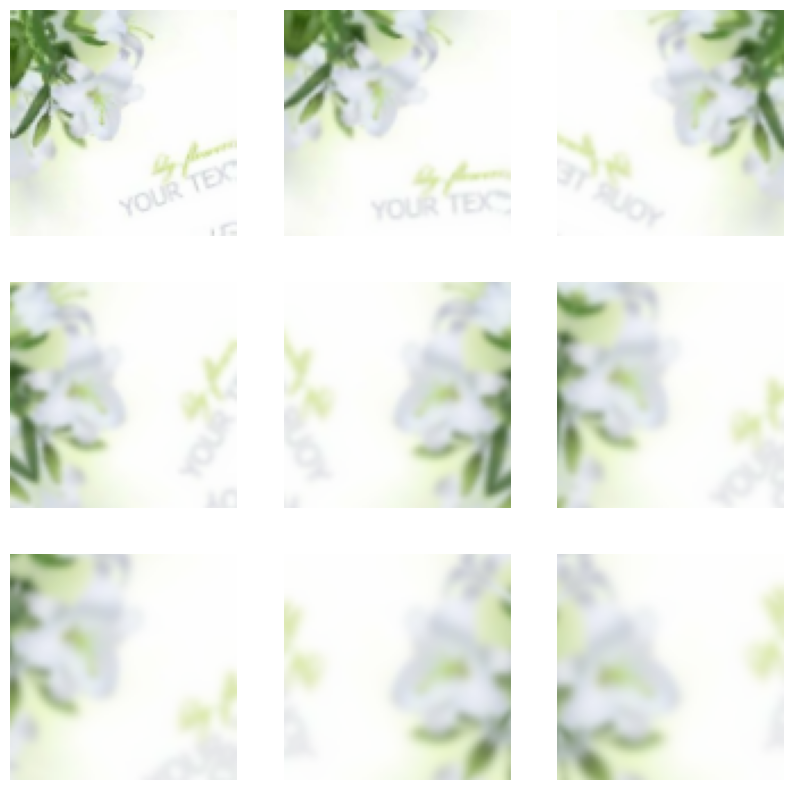

In [27]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    images=data_augumentation(images)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.axis('off')

In [28]:
#model creation
model=Sequential([
    data_augumentation,
    layers.Rescaling(1./255),
    Conv2D(16,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(32,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(64,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(5)
])

In [29]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,204,005 (4.59 MB)

 Trainable params: 1,204,005 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history=model.fit(train_ds,validation_data=val_ds,epochs=10)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4113 - loss: 1.3567 - val_accuracy: 0.5255 - val_loss: 1.1650
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5484 - loss: 1.0875 - val_accuracy: 0.6056 - val_loss: 1.0020
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6155 - loss: 0.9813 - val_accuracy: 0.6226 - val_loss: 0.9312
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6494 - loss: 0.9193 - val_accuracy: 0.6376 - val_loss: 0.9434
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6468 - loss: 0.8703 - val_accuracy: 0.6767 - val_loss: 0.8669
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6723 - loss: 0.8433 - val_accuracy: 0.6346 - val_loss: 0.9713
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6944 - loss: 0.7994 - val_accuracy: 0.7017 - val_loss: 0.7695
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7066 - loss: 0.7459 - val_accu

In [50]:
print(flower_names )

['lily', 'lotus', 'orchid', 'sunflower', 'tulip']


In [64]:
def classify_imags(image_path):
 input_image = tf.keras.utils.load_img(image_path, target_size=(100, 100))
 input_image_array = tf.keras.utils.img_to_array(input_image)
 input_image_array = np.expand_dims(input_image_array,0)
 predictions=model.predict(input_image_array)
 result=tf.nn.softmax(predictions[0])
 predicted_class = np.argmax(result)
 print(flower_names[predicted_class])
 print("With the accuracy of :",result[predicted_class]*100,"%")




In [65]:
classify_imags('/content/sample.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
lotus
With the accuracy of : tf.Tensor(96.10072, shape=(), dtype=float32) %


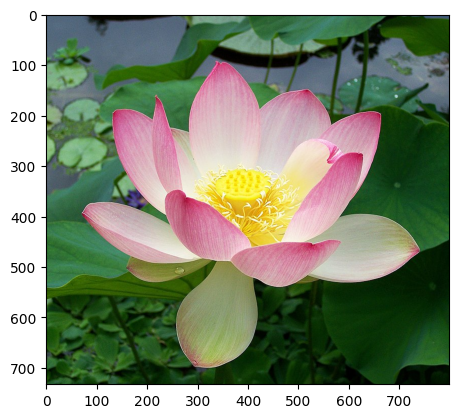

In [67]:

img=mpimg.imread('/content/sample.jpg')
imgplot=plt.imshow(img)
plt.show()

**Model is Predicting with accuracy where lotus was predicted as lotus**

In [66]:
classify_imags('/content/sample2.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
lily
With the accuracy of : tf.Tensor(96.84083, shape=(), dtype=float32) %


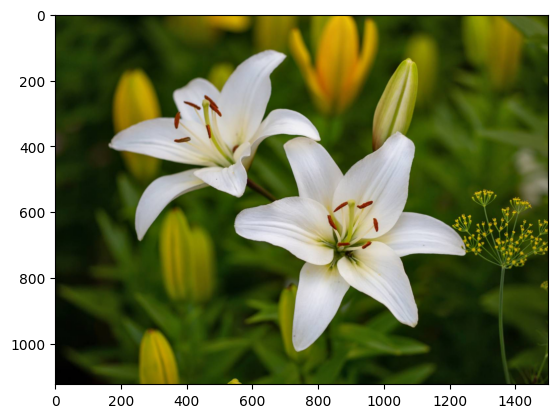

In [68]:
img=mpimg.imread('/content/sample2.jpg')
imgplot=plt.imshow(img)
plt.show()

**Model is Predicting with accuracy where lily was predicted as lily**